<!-- NINO26-CABECALHO v1 -->
# 3H — Gênese: o que separa as classes NOAA de El Niño?

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3H`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Caracteriza o estado precursor (pré-onset) e testa se ele já separa as classes de intensidade — o pré-condicionamento de recarga como discriminante da magnitude futura.

## Pergunta
Que valores as variáveis assumem antes do onset e o estado precursor separa fraco/moderado/forte/muito forte?

## Desafio (hipótese a testar)
Rótulos de gênese não podem usar informação futura; o discriminante deve ser causal (só dados até o pré-onset).

## Metodologia (com referências)
Compostos alinhados ao onset e ciclo de vida médio de sub/superfície+atmosfera por classe (recarga de Jin, 1997; Meinen & McPhaden, 2000).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução. A fonte deve ser uma tabela persistida com sidecar e hash do mesmo `run_id`:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3H01", fase=3, bloco="H",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3H_genese_precursores_classe.ipynb",
                 run_id=run.run_id,
                 fontes={"<tabela>": tabela_path})   # Path + .manifest.json -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3H01` | `Fig_3H01.png` | `Fig_3H01/` | compostos alinhados ao onset |
| `Fig_3H02` | `Fig_3H02.png` | `Fig_3H02/` | ciclo de vida médio |
| `Fig_3H03` | `Fig_3H03.png` | `Fig_3H03/` | ciclo de vida subsuperfície+atmosfera |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; compatibilidade por `python scripts/validar_figuras.py --strict --allow-render-extraction`; promoção por `python scripts/validar_figuras.py --strict`.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.DERIVED_FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_noaa().copy()
prov=ev[['event_id','classe_noaa','event_start','peak_time','event_end','duration_oni_seasons','peak_oni_local_c','peak_monthly_ssta_c']].copy()
prov.columns=['evento','classe','onset','pico','fim','duracao_estacoes_oni','oni_pico_c','ssta_mensal_pico_c']
u.save_table(prov,'phase3H_proveniencia_eventos.csv',index=False)
counts=prov['classe'].value_counts().to_dict()
print('PROVENIENCIA NOAA/ONI local - '+', '.join(f'{k} n={counts.get(k,0)}' for k in u.ELNINO_MEAN_GROUP_ORDER))
print(prov[['evento','classe','onset']].to_string(index=False))


[tabela semântica] data\processed\parquet\statistics\phase3H_proveniencia_eventos.csv
PROVENIENCIA NOAA/ONI local - fraco n=4, moderado n=2, forte n=3, muito_forte n=3
                 evento      classe      onset
el_nino_oisst_1982_1983 muito_forte 1982-07-01
el_nino_oisst_1986_1988    moderado 1986-10-01
el_nino_oisst_1991_1992       forte 1991-09-01
el_nino_oisst_1994_1995       fraco 1994-10-01
el_nino_oisst_1997_1998 muito_forte 1997-06-01
el_nino_oisst_2002_2003    moderado 2002-07-01
     el_nino_oisst_2004       fraco 2004-08-01
el_nino_oisst_2006_2007       fraco 2006-09-01
el_nino_oisst_2009_2010       forte 2009-07-01
el_nino_oisst_2014_2016 muito_forte 2014-10-01
el_nino_oisst_2018_2019       fraco 2018-10-01
el_nino_oisst_2023_2024       forte 2023-05-01


[tabela semântica] data\processed\parquet\statistics\phase3H_compostos_onset.csv


[tabela semântica] data\processed\parquet\statistics\phase3H_grupos_classes_noaa.csv


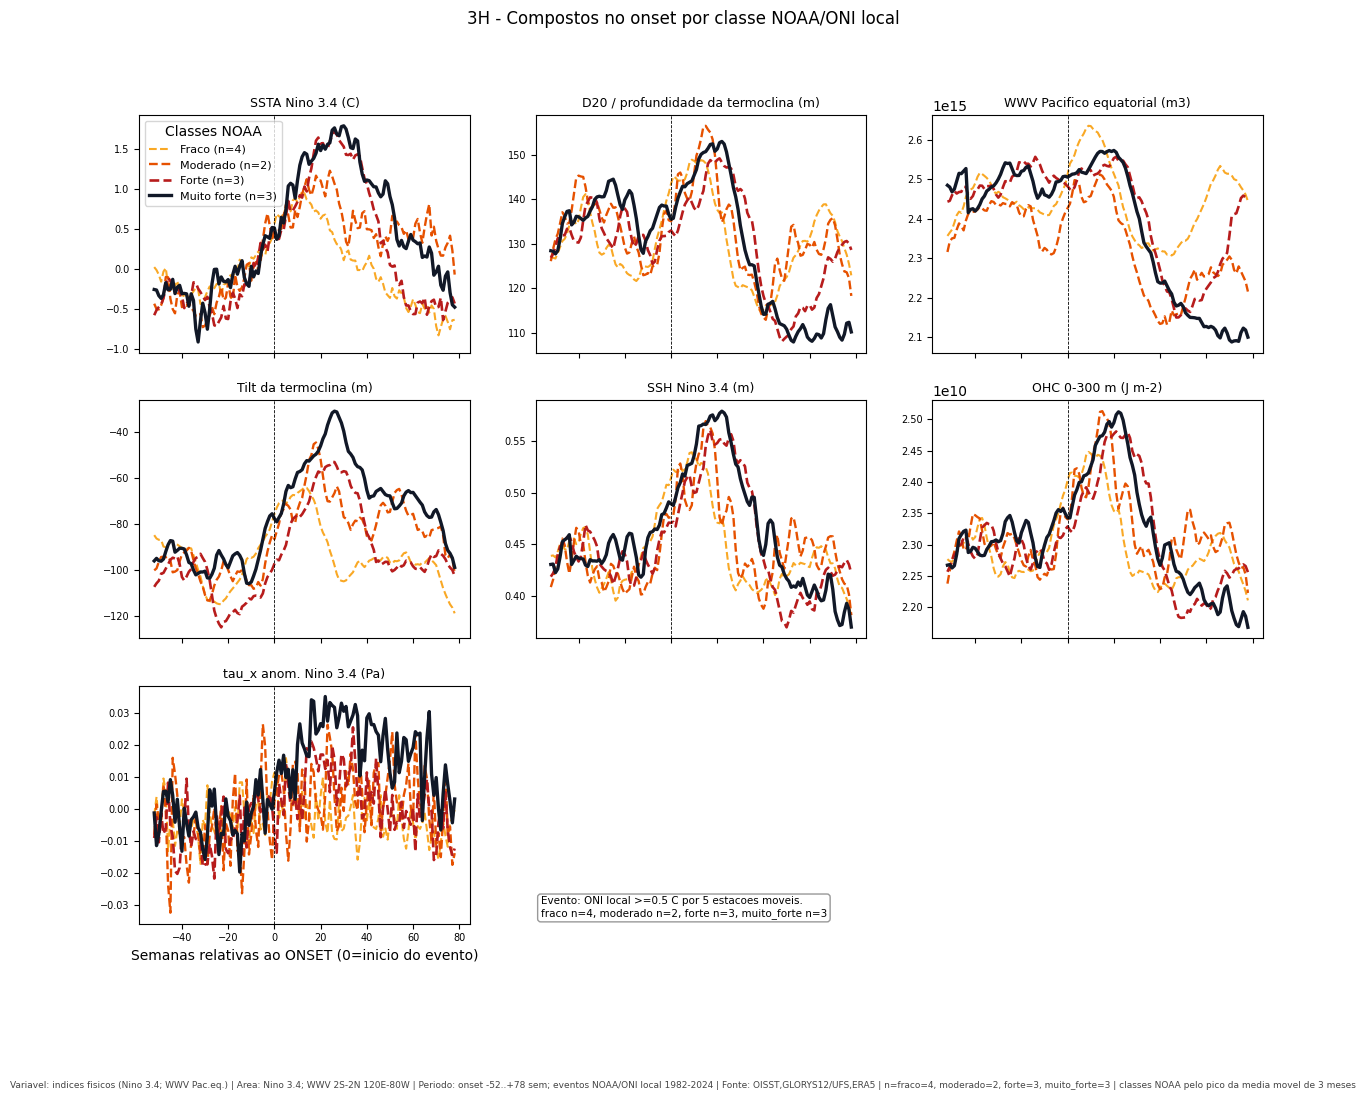

In [2]:
VARS=['nino34_ssta','d20_m','wwv','tilt_m','ssh_m','ohc_0_300','tau_x_anom_nino34_pa']; LAGS=list(range(-52,79))
def onset_al(s,o):
    i=s.index.get_indexer([o],method='nearest')[0]; seg=s.iloc[max(0,i-52):i+79]
    rel=((seg.index-s.index[i]).days/7).round().astype(int); return pd.Series(seg.values,index=rel).reindex(LAGS)
groups=u.elnino_mean_groups(ev)
comps={g:pd.DataFrame({v:pd.DataFrame([onset_al(w[v],e.event_start) for _,e in gg.iterrows()]).mean() for v in VARS}) for g,gg in groups.items() if len(gg)>0}
comps['todos_elnino_noaa']=pd.DataFrame({v:pd.DataFrame([onset_al(w[v],e.event_start) for _,e in ev.iterrows()]).mean() for v in VARS})
u.save_table(pd.concat({g:v for g,v in comps.items() if g!='todos_elnino_noaa'},names=['grupo','sem_rel_onset']), 'phase3H_compostos_onset.csv')
u.save_table(u.elnino_mean_group_table()[['grupo','rotulo','definicao']],'phase3H_grupos_classes_noaa.csv',index=False)
fig,axes=plt.subplots(3,3,figsize=(14.5,10.5),sharex=True)
for ax,v in zip(axes.flat,VARS):
    for g in u.ELNINO_MEAN_GROUP_ORDER:
        if g in comps:
            meta=u.elnino_group_style(g)
            ax.plot(LAGS,comps[g][v],color=meta['color'],label=f"{meta['rotulo_curto']} (n={len(groups[g])})",lw=meta['linewidth'],ls=meta['linestyle'])
    ax.axvline(0,color='k',ls='--',lw=.6); ax.set_title(u.var_label(v),fontsize=9); ax.tick_params(labelsize=7)
axes.flat[0].legend(fontsize=8,title='Classes NOAA')
for ax in axes[-1]: ax.set_xlabel('Semanas relativas ao ONSET (0=inicio do evento)')
for ax in axes.flat[len(VARS):]: ax.axis('off')
counts=ev['classe_noaa'].value_counts().to_dict()
fig.suptitle('3H - Compostos no onset por classe NOAA/ONI local')
u.add_note(axes.flat[-2], 'Evento: ONI local >=0.5 C por 5 estacoes moveis.\n' + ', '.join(f'{k} n={counts.get(k,0)}' for k in u.ELNINO_MEAN_GROUP_ORDER), loc='lower left')
u.stamp_caption(fig,variavel='indices fisicos (Nino 3.4; WWV Pac.eq.)',area='Nino 3.4; WWV 2S-2N 120E-80W',periodo='onset -52..+78 sem; eventos NOAA/ONI local 1982-2024',fonte='OISST,GLORYS12/UFS,ERA5',n=', '.join(f"{k}={counts.get(k,0)}" for k in u.ELNINO_MEAN_GROUP_ORDER),extra='classes NOAA pelo pico da media movel de 3 meses')
u.save_fig(fig,'3H1_compostos_onset.png', fontes={'compostos': 'phase3H_compostos_onset.csv', 'classes': 'phase3H_grupos_classes_noaa.csv'}); plt.show()


[tabela semântica] data\processed\parquet\statistics\phase3H_fases_ciclo_vida.csv


[tabela semântica] data\processed\parquet\statistics\phase3H_ciclo_vida_media.csv


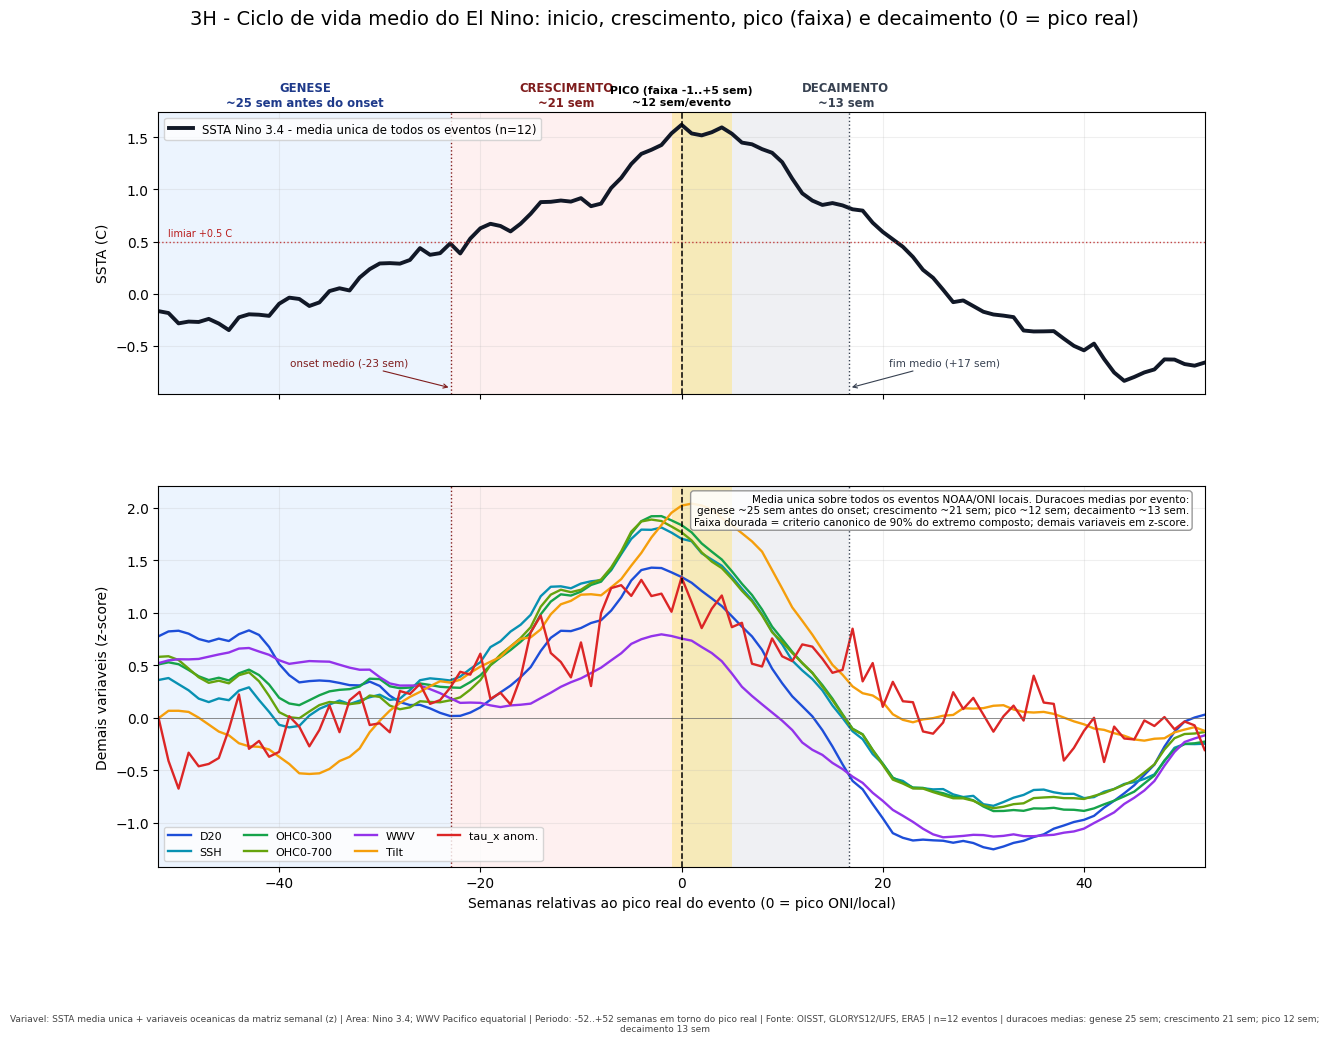

In [3]:
# Ciclo de vida MEDIO alinhado ao pico real, com as fases mapeadas no grafico e o
# pico tratado como FAIXA canonica (SSTA composta >= 90% do extremo).
REL = list(range(-52, 53))

def peak_al(s, peak):
    i = s.index.get_indexer([peak], method='nearest')[0]
    seg = s.iloc[max(0, i-52):i+53]
    rel = ((seg.index - s.index[i]).days/7).round().astype(int)
    return pd.Series(seg.values, index=rel).reindex(REL)

def comp_z(v):
    z = (w[v] - w[v].mean()) / w[v].std()
    return pd.DataFrame([peak_al(z, e.peak_time) for _, e in ev.iterrows()]).mean()

ssta_comp = pd.DataFrame([peak_al(w['nino34_ssta'], e.peak_time) for _, e in ev.iterrows()]).mean()
onset_off = float(np.mean([(e.event_start - e.peak_time).days/7 for _, e in ev.iterrows()]))
end_off = float(np.mean([(e.event_end - e.peak_time).days/7 for _, e in ev.iterrows()]))
# faixa de pico composta: semanas com SSTA composta >= 90% do maximo
band = ssta_comp[ssta_comp >= 0.90 * ssta_comp.max()]
b0, b1 = float(band.index.min()), float(band.index.max())
life_path = u.STATS/'phase3_event_lifecycle_en_ln.csv'
if life_path.exists():
    life = pd.read_csv(life_path)
    fase_dur = life[life['tipo'].eq('el_nino')].groupby('fase')['duracao_semanas'].mean().to_dict()
else:
    fase_dur = {}
genese_sem = float(fase_dur.get('genese', 26.0))
crescimento_sem = float(fase_dur.get('crescimento', -onset_off))
pico_sem = float(fase_dur.get('pico', b1-b0+1))
decaimento_sem = float(fase_dur.get('decaimento', end_off))

def phase_decor(ax):
    ax.axvspan(-52, onset_off, color='#dbeafe', alpha=.5, lw=0)
    ax.axvspan(onset_off, 0, color='#fee2e2', alpha=.5, lw=0)
    ax.axvspan(0, end_off, color='#e5e7eb', alpha=.6, lw=0)
    ax.axvspan(b0, b1, color='#fde68a', alpha=.55, lw=0)
    ax.axvline(0, color='k', ls='--', lw=1.1)
    ax.axvline(onset_off, color='#7f1d1d', ls=':', lw=1)
    ax.axvline(end_off, color='#374151', ls=':', lw=1)
    ax.grid(alpha=.2)
    ax.set_xlim(-52, 52)

VARS_Z = ['d20_m','ssh_m','ohc_0_300','ohc_0_700','wwv','tilt_m','tau_x_anom_nino34_pa']
zcomp = {v: comp_z(v) for v in VARS_Z}
fases = pd.DataFrame([
    {'fase':'inicio (genese)','de_sem':-52,'ate_sem':round(onset_off,1),'criterio':'antes do onset medio (ONI local cruza +0.5 C)'},
    {'fase':'crescimento','de_sem':round(onset_off,1),'ate_sem':0,'criterio':'do onset medio ate o pico real'},
    {'fase':'pico (faixa)','de_sem':round(b0,1),'ate_sem':round(b1,1),'criterio':'semanas com SSTA composta >= 90% do maximo (sensibilidade oficial 80/90/95%)'},
    {'fase':'decaimento','de_sem':0,'ate_sem':round(end_off,1),'criterio':'do pico ate o fim medio do evento'},
])
u.save_table(fases,'phase3H_fases_ciclo_vida.csv',index=False)
tab = pd.DataFrame({'semana_rel_pico':REL,'ssta_media_c':ssta_comp.values, **{f'{v}_z':zcomp[v].values for v in VARS_Z}})
tab['n_eventos'] = len(ev)
u.save_table(tab,'phase3H_ciclo_vida_media.csv',index=False)

CORES = {'d20_m':'#1d4ed8','ssh_m':'#0891b2','ohc_0_300':'#16a34a','ohc_0_700':'#65a30d','wwv':'#9333ea','tilt_m':'#f59e0b','tau_x_anom_nino34_pa':'#dc2626'}
fig, axes = plt.subplots(2, 1, figsize=(13.5, 9.8), sharex=True, gridspec_kw={'height_ratios':[1, 1.35]})
axes[0].plot(REL, ssta_comp.values, color='#111827', lw=2.8, label=f'SSTA Nino 3.4 - media unica de todos os eventos (n={len(ev)})')
axes[0].axhline(0.5, color='#b91c1c', ls=':', lw=1, alpha=.8)
axes[0].text(-51, 0.55, 'limiar +0.5 C', fontsize=7, color='#b91c1c')
axes[0].set_ylabel('SSTA (C)')
axes[0].legend(fontsize=8.5, loc='upper left')
for v in VARS_Z:
    axes[1].plot(REL, zcomp[v].values, color=CORES[v], lw=1.7, label=u.var_label(v, short=True))
axes[1].axhline(0, color='0.4', lw=.5)
axes[1].set_ylabel('Demais variaveis (z-score)')
axes[1].set_xlabel('Semanas relativas ao pico real do evento (0 = pico ONI/local)')
axes[1].legend(fontsize=8, ncol=4, loc='lower left')
for ax in axes: phase_decor(ax)
trans = axes[0].get_xaxis_transform()
axes[0].text((-52+onset_off)/2, 1.02, f'GENESE\n~{genese_sem:.0f} sem antes do onset', transform=trans, ha='center', fontsize=8.4, color='#1e3a8a', weight='bold')
axes[0].text(onset_off/2, 1.02, f'CRESCIMENTO\n~{crescimento_sem:.0f} sem', transform=trans, ha='center', fontsize=8.4, color='#7f1d1d', weight='bold')
axes[0].text(0, 1.025, f'PICO (faixa {b0:.0f}..{b1:+.0f} sem)\n~{pico_sem:.0f} sem/evento', transform=trans, ha='center', fontsize=7.8, color='k', weight='bold')
axes[0].text(end_off/2+8, 1.02, f'DECAIMENTO\n~{decaimento_sem:.0f} sem', transform=trans, ha='center', fontsize=8.4, color='#374151', weight='bold')
axes[0].annotate(f'onset medio ({onset_off:.0f} sem)', xy=(onset_off, 0.02), xycoords=trans, xytext=(onset_off-16, 0.10), textcoords=trans, fontsize=7.5, color='#7f1d1d', arrowprops={'arrowstyle':'->','color':'#7f1d1d','lw':.8})
axes[0].annotate(f'fim medio (+{end_off:.0f} sem)', xy=(end_off, 0.02), xycoords=trans, xytext=(end_off+4, 0.10), textcoords=trans, fontsize=7.5, color='#374151', arrowprops={'arrowstyle':'->','color':'#374151','lw':.8})
fig.subplots_adjust(top=0.88, hspace=0.28)
fig.suptitle('3H - Ciclo de vida medio do El Nino: inicio, crescimento, pico (faixa) e decaimento (0 = pico real)', y=0.985, fontsize=14)
u.add_note(axes[1], f'Media unica sobre todos os eventos NOAA/ONI locais. Duracoes medias por evento:\ngenese ~{genese_sem:.0f} sem antes do onset; crescimento ~{crescimento_sem:.0f} sem; pico ~{pico_sem:.0f} sem; decaimento ~{decaimento_sem:.0f} sem.\nFaixa dourada = criterio canonico de 90% do extremo composto; demais variaveis em z-score.', loc='upper right')
u.stamp_caption(fig, variavel='SSTA media unica + variaveis oceanicas da matriz semanal (z)', area='Nino 3.4; WWV Pacifico equatorial', periodo='-52..+52 semanas em torno do pico real', fonte='OISST, GLORYS12/UFS, ERA5', n=f'{len(ev)} eventos', extra=f'duracoes medias: genese {genese_sem:.0f} sem; crescimento {crescimento_sem:.0f} sem; pico {pico_sem:.0f} sem; decaimento {decaimento_sem:.0f} sem')
u.save_fig(fig, '3H2_ciclo_vida.png', fontes={'ciclo_medio': 'phase3H_ciclo_vida_media.csv', 'fases': 'phase3H_fases_ciclo_vida.csv'})
plt.show()


[tabela semântica] data\processed\parquet\statistics\phase3H_ciclo_vida_media_subsuperficie_atmosfera.csv


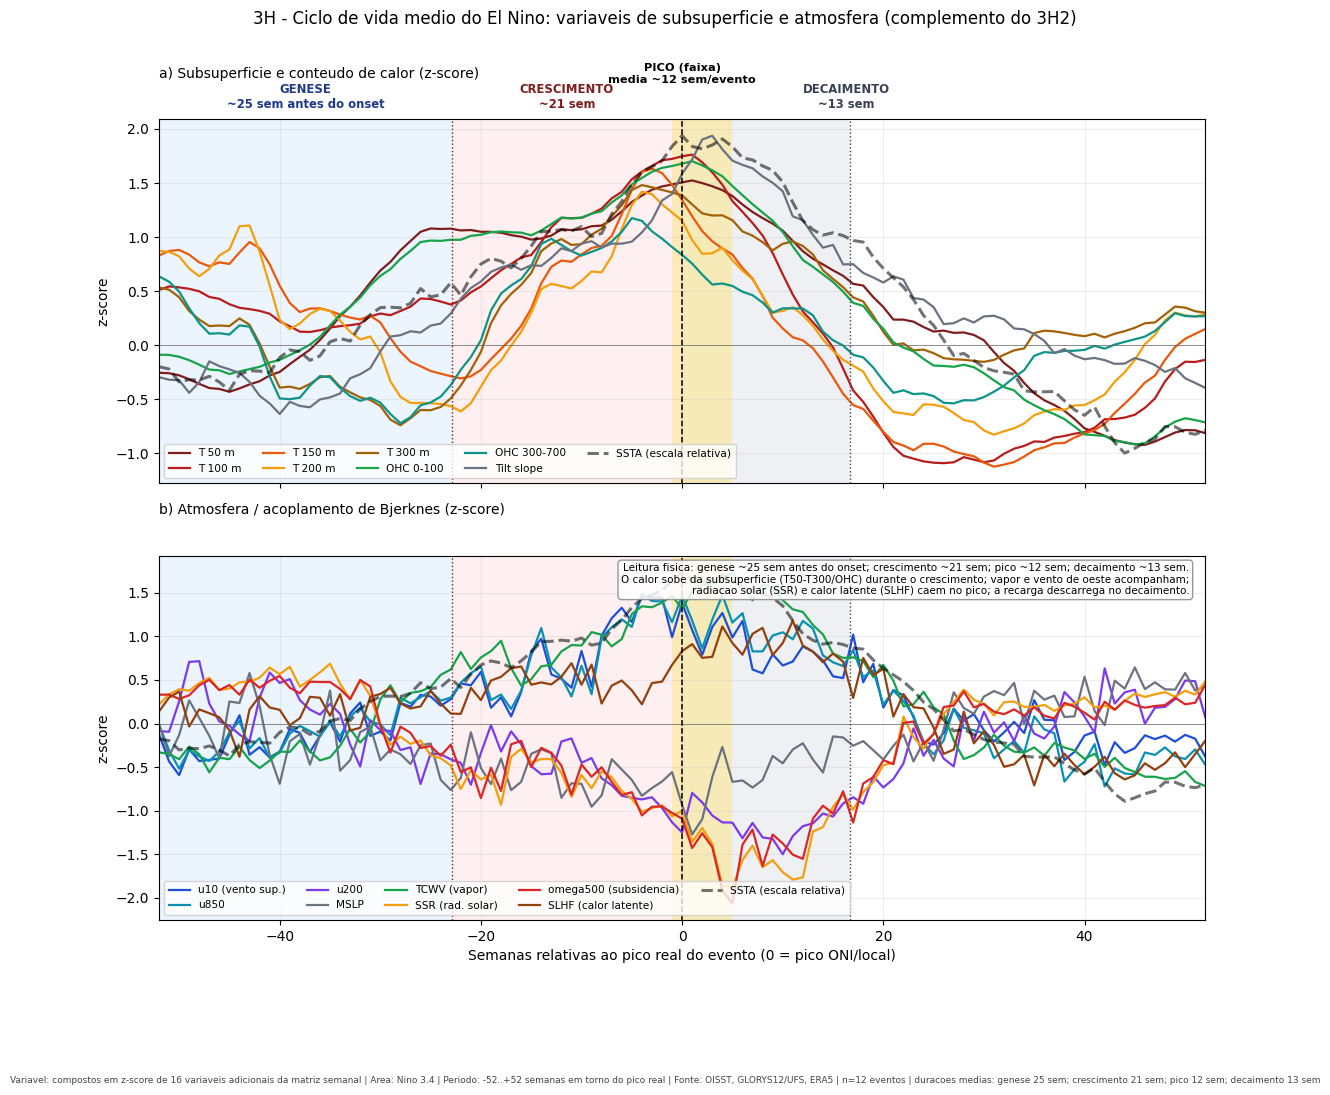

faixa de pico composta: -1.0 a 5.0 semanas


In [4]:
# ---------- 3H3 (NOVO): subsuperficie e atmosfera no ciclo de vida ----------
SUBS = ['t50m','t100m','t150m','t200m','t300m','ohc_0_100','ohc_300_700','tilt_slope']
ATMO = ['u10_anom','u850_anom','u200_anom','mslp_anom','tcwv_anom','ssr_anom','omega500_anom','slhf_anom']
subs = {v: comp_z(v) for v in SUBS}
atmo = {v: comp_z(v) for v in ATMO}
tab2 = pd.DataFrame({'semana_rel_pico': REL, 'ssta_media_c': ssta_comp.values,
                     **{f'{v}_z': subs[v].values for v in SUBS},
                     **{f'{v}_z': atmo[v].values for v in ATMO}})
tab2['n_eventos'] = len(ev)
u.save_table(tab2, 'phase3H_ciclo_vida_media_subsuperficie_atmosfera.csv', index=False)

C1 = {'t50m':'#7f1d1d','t100m':'#b91c1c','t150m':'#ea580c','t200m':'#f59e0b','t300m':'#a16207','ohc_0_100':'#16a34a','ohc_300_700':'#0d9488','tilt_slope':'#6b7280'}
C2 = {'u10_anom':'#1d4ed8','u850_anom':'#0891b2','u200_anom':'#7c3aed','mslp_anom':'#6b7280','tcwv_anom':'#16a34a','ssr_anom':'#f59e0b','omega500_anom':'#dc2626','slhf_anom':'#92400e'}
LBL = {'t50m':'T 50 m','t100m':'T 100 m','t150m':'T 150 m','t200m':'T 200 m','t300m':'T 300 m','ohc_0_100':'OHC 0-100','ohc_300_700':'OHC 300-700','tilt_slope':'Tilt slope',
       'u10_anom':'u10 (vento sup.)','u850_anom':'u850','u200_anom':'u200','mslp_anom':'MSLP','tcwv_anom':'TCWV (vapor)','ssr_anom':'SSR (rad. solar)','omega500_anom':'omega500 (subsidencia)','slhf_anom':'SLHF (calor latente)'}
fig, axes = plt.subplots(2, 1, figsize=(13.5, 10.4), sharex=True)
for ax, grp, cores, tit in [(axes[0], subs, C1, 'a) Subsuperficie e conteudo de calor (z-score)'),
                             (axes[1], atmo, C2, 'b) Atmosfera / acoplamento de Bjerknes (z-score)')]:
    ax2 = ax
    for v, s in grp.items():
        ax.plot(REL, s.values, color=cores[v], lw=1.6, label=LBL[v])
    ax.plot(REL, (ssta_comp/ssta_comp.abs().max()*max(abs(np.nanmax([s.values for s in grp.values()])), 1.6)).values,
            color='k', lw=2.2, ls='--', alpha=.55, label='SSTA (escala relativa)')
    ax.axhline(0, color='0.4', lw=.5)
    ax.set_ylabel('z-score')
    ax.set_title(tit, fontsize=10, loc='left', pad=30)
    ax.legend(fontsize=7.6, ncol=5, loc='lower left')
    phase_decor(ax)
trans = axes[0].get_xaxis_transform()
axes[0].text((-52+onset_off)/2, 1.03, f'GENESE\n~{genese_sem:.0f} sem antes do onset', transform=trans, ha='center', fontsize=8.4, color='#1e3a8a', weight='bold')
axes[0].text(onset_off/2, 1.03, f'CRESCIMENTO\n~{crescimento_sem:.0f} sem', transform=trans, ha='center', fontsize=8.4, color='#7f1d1d', weight='bold')
axes[0].text(0, 1.10, f'PICO (faixa)\nmedia ~{pico_sem:.0f} sem/evento', transform=trans, ha='center', fontsize=8.2, color='k', weight='bold')
axes[0].text(end_off/2+8, 1.03, f'DECAIMENTO\n~{decaimento_sem:.0f} sem', transform=trans, ha='center', fontsize=8.4, color='#374151', weight='bold')
axes[1].set_xlabel('Semanas relativas ao pico real do evento (0 = pico ONI/local)')
fig.suptitle('3H - Ciclo de vida medio do El Nino: variaveis de subsuperficie e atmosfera (complemento do 3H2)', y=0.985)
u.add_note(axes[1], f'Leitura fisica: genese ~{genese_sem:.0f} sem antes do onset; crescimento ~{crescimento_sem:.0f} sem; pico ~{pico_sem:.0f} sem; decaimento ~{decaimento_sem:.0f} sem.\nO calor sobe da subsuperficie (T50-T300/OHC) durante o crescimento; vapor e vento de oeste acompanham;\nradiacao solar (SSR) e calor latente (SLHF) caem no pico; a recarga descarrega no decaimento.', loc='upper right')
u.stamp_caption(fig, variavel='compostos em z-score de 16 variaveis adicionais da matriz semanal', area='Nino 3.4', periodo='-52..+52 semanas em torno do pico real', fonte='OISST, GLORYS12/UFS, ERA5', n=f'{len(ev)} eventos', extra=f'duracoes medias: genese {genese_sem:.0f} sem; crescimento {crescimento_sem:.0f} sem; pico {pico_sem:.0f} sem; decaimento {decaimento_sem:.0f} sem')
u.save_fig(fig, '3H3_ciclo_vida_subsuperficie_atmosfera.png', fontes={'ciclo_subsuperficie_atmosfera': 'phase3H_ciclo_vida_media_subsuperficie_atmosfera.csv', 'fases': 'phase3H_fases_ciclo_vida.csv'})
plt.show()
print('faixa de pico composta:', b0, 'a', b1, 'semanas')


In [5]:
from scipy.stats import spearmanr
marcos=[-26,-13,0]; rows=[]
for g,gg in ev.groupby('classe_noaa'):
    for v in VARS:
        vals={m:[] for m in marcos}
        for _,e in gg.iterrows():
            s=onset_al(w[v],e.event_start)
            for m in marcos: vals[m].append(s.loc[m-2:m+2].mean())
        row={'classe':g,'variavel':v}
        for m in marcos:
            a=pd.Series(vals[m]).dropna(); row[f'media_{m}s']=round(a.mean(),3); row[f'range_{m}s']=f'{a.min():.2f}..{a.max():.2f}'
        rows.append(row)
u.save_table(pd.DataFrame(rows),'phase3H_estado_precursor_por_classe.csv',index=False)
rows=[]
for v in VARS:
    pre=[];it=[]
    for _,e in ev.iterrows():
        s=onset_al(w[v],e.event_start); pre.append(s.loc[-26:0].mean()); it.append(e.peak_oni_local_c if 'peak_oni_local_c' in e else e.peak_ssta_c)
    m=pd.notna(pre); rho,p=spearmanr(pd.Series(pre)[m],pd.Series(it)[m])
    rows.append({'variavel':v,'spearman_rho':round(float(rho),3),'p_bruto':round(float(p),3),'n':int(m.sum())})
sep=pd.DataFrame(rows).sort_values('spearman_rho',key=abs,ascending=False); u.save_table(sep,'phase3H_separacao_genese.csv',index=False)
print('SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs pico ONI local; eventos NOAA):')
for _,r in sep.iterrows(): print(f"  {r.variavel:24s} rho={r.spearman_rho:+.2f} (p={r.p_bruto:.2f})")


[tabela semântica] data\processed\parquet\statistics\phase3H_estado_precursor_por_classe.csv


[tabela semântica] data\processed\parquet\statistics\phase3H_separacao_genese.csv
SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs pico ONI local; eventos NOAA):
  d20_m                    rho=+0.55 (p=0.07)
  ohc_0_300                rho=+0.34 (p=0.28)
  wwv                      rho=+0.28 (p=0.38)
  tilt_m                   rho=+0.22 (p=0.50)
  tau_x_anom_nino34_pa     rho=+0.20 (p=0.54)
  ssh_m                    rho=+0.19 (p=0.56)
  nino34_ssta              rho=+0.06 (p=0.85)


**Leitura do 3H.** A genese compara as classes NOAA/ONI local no onset (`3H1_compostos_onset.png`); o ciclo de vida (`3H2_ciclo_vida.png`) mapeia as quatro fases com duracao explicita. A faixa dourada usa o contrato canonico de 90% do extremo (com sensibilidade 80/90/95% na tabela F3). O `3H3_ciclo_vida_subsuperficie_atmosfera.png` completa o quadro com subsuperficie e atmosfera. Esta leitura e diagnostica e retrospectiva; previsao usa as origens e horizontes de `phase3_rolling_origin_targets.csv`.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Jin, F.-F. (1997). An Equatorial Ocean Recharge Paradigm for ENSO. Part I. *J. Atmos. Sci.*, 54, 811-829. https://doi.org/10.1175/1520-0469(1997)054<0811:AEORPF>2.0.CO;2
2. Meinen, C. S., & McPhaden, M. J. (2000). Observations of Warm Water Volume Changes... *J. Climate*, 13, 3551-3559. https://doi.org/10.1175/1520-0442(2000)013<3551:OOWWVC>2.0.CO;2

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.